# Табличные данные

**Цель**: провести анализ табличных данных с помощью средств языка программирования Python

**Выполнил:** ст.группы 24ВВИ1 Будников А.С.

## Теоретическая часть

### 1. Что такое описательная статистика и какова её основная цель при анализе данных?

Это раздел статистики, который занимается систематизацией, представлением и анализом характеристик данных с целью их описания, но без попыток делать выводы о более широкой совокупности. Ее основная цель заключается в том, чтобы выявить закономерные характеристики изменчивости отдельных признаков. Эта цель достигается посредством решения трех ключевых задач описательной статистики:
1. оценка центральной тенденции (середины, центра) распределения;
2. оценка отклонений от центра распределения — разброса;
3. анализ закона распределения переменной (задача актуальна только для величин, т.е. параметрических переменных).

### 2. Чем отличаются: среднее арифметическое; медиана; минимальное и максимальное значения?

* Чаще всего под средним арифметическим подразумывается сумма всех значений случайной величины, деленная на общее количество наблюдений. Эта величина крайне чувствительна к выбросам, то есть при появлении экстремальных значений ее величина сильно меняется (искажается).
* Медиана - такое число, характеризующее выборку, что ровно половина выборки меньше него, а ровно половина - больше. Она делит выборку пополам. Медиана, в отличие от среднего арифметического, устойчива к выбросам, следовательно она обеспечивает лучшее представление о "типичном" значении.
* Минимальное и максимальное значения - крайние значения в выборке, показывающию размах значений в наборе данных. Как и среднее арифметическое чувствительны к выбросам, а следственно могут дать ложное представление о данных без дополнительных критериев оценки.

### 3. Какие задачи решает метод describe() в библиотеке pandas?

Метод describe() позволяет получить сводку описательных характеристик по количественным переменным датафрейма. В числе таких характеристик:
* сount - количество значений
* mean - среднее арифметическое
* std - стандартное отклонение
* min - минимимальное значение
* 25% - 25-й процентиль
* 50% - медиана
* 75% - 75-й процентиль
* max - максимальное значение

При передаче параметра способен выводить и характеристику категориальных столбцов.

### 4. Что такое квантили и какую информацию они дают о распределении данных?

Квантиль - значение, которое заданная случайная величина не превышает с фиксированной вероятностью, или делит упорядоченный набор данных на несколько частей. Квантили позволяют получить информацию о форме распределения и его разбросе

### 5. Что называется разбросом данных и какими статистическими показателями он описывается?

Разброс - мера, которая показывает насколько значения в выборке отличаются от центра распределения. 

К основным показателям относятся: 
* дисперсия
* среднеквадратичное отклонение
* процентили
* размах

Можно сюда же отнести смещение

### 6. Какие статистические признаки могут указывать на наличие выбросов в данных?

1. Сравнение разницы между средним значением и медианой, так как вторая от выбросов не зависит
2. График
3. Аномальные значения минимального и максимального

## Практическая часть (повышенный уровень)

In [1]:
# base
import numpy as np
import pandas as pd
# visualization
import seaborn as sns
import matplotlib.pyplot as plt

## Анализ

Помимо "стандартных" библиотек **pandas** и **numpy**, которые также использовались в лабораторно работе №2, были также импортированы библиотекуи для визуализации даных: **seaborn** и **matplotlib**. Обе были использованы для построения тепловой карты.

In [2]:
df = pd.read_csv('data/covtype.csv') # default delimiter is ','
df.head() # default is 5

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [3]:
renamed_cols = {
    'Elevation': 'Высота_над_уровнем_моря',
    'Aspect': 'Азимут_склона',
    'Slope': 'Уклон_склона',
    'Horizontal_Distance_To_Hydrology': 'Расстояние_до_воды_гориз',
    'Vertical_Distance_To_Hydrology': 'Расстояние_до_воды_верт',
    'Horizontal_Distance_To_Roadways': 'Расстояние_до_дорог',
    'Hillshade_9am': 'Освещённость_9_утра',
    'Hillshade_Noon': 'Освещённость_полдень',
    'Hillshade_3pm': 'Освещённость_3_дня',
    'Horizontal_Distance_To_Fire_Points': 'Расстояние_до_пожарных_точек',
    'Cover_Type': 'Тип_лесного_покрова',
}
for i in range(1, 5):
    renamed_cols[f'Wilderness_Area{i}'] = f'Зона_дикой_природы_{i}'

for i in range(1, 41):
    renamed_cols[f'Soil_Type{i}'] = f'Тип_почвы_{i}'

df = df.rename(columns=renamed_cols)

In [4]:
print(f"Rows={df.shape[0]}", f"Columns={df.shape[1]}", sep='\t')

Rows=581012	Columns=55


## Анализ

В качестве датасета используется [Forest Cover Types](https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset/data).
Здесь содержатся данные о типах лесного покрова для территорий национального парка Рузвельта в Колорадо США. Каждая строка таблицы описывает один участок земли площадью 30×30 метров. Набор признаков включает информацию о типе дерева, степени затенения, расстоянии до близлежащих ориентиров (дорог и т. д.), типе почвы и местном рельефе. 

Всего в датасете 581 012 записей и 55 столбцов как показано выше. Для удобства чтения столбцы были переименованы

In [5]:
print(df.dtypes)

Высота_над_уровнем_моря         int64
Азимут_склона                   int64
Уклон_склона                    int64
Расстояние_до_воды_гориз        int64
Расстояние_до_воды_верт         int64
Расстояние_до_дорог             int64
Освещённость_9_утра             int64
Освещённость_полдень            int64
Освещённость_3_дня              int64
Расстояние_до_пожарных_точек    int64
Зона_дикой_природы_1            int64
Зона_дикой_природы_2            int64
Зона_дикой_природы_3            int64
Зона_дикой_природы_4            int64
Тип_почвы_1                     int64
Тип_почвы_2                     int64
Тип_почвы_3                     int64
Тип_почвы_4                     int64
Тип_почвы_5                     int64
Тип_почвы_6                     int64
Тип_почвы_7                     int64
Тип_почвы_8                     int64
Тип_почвы_9                     int64
Тип_почвы_10                    int64
Тип_почвы_11                    int64
Тип_почвы_12                    int64
Тип_почвы_13

In [6]:
print(df.nunique())
categorical_cols = [col for col in df.columns if df[col].nunique() == 2]
numeric_cols = [col for col in df.columns if df[col].nunique() > 2 and col != 'Тип_лесного_покрова']

Высота_над_уровнем_моря         1978
Азимут_склона                    361
Уклон_склона                      67
Расстояние_до_воды_гориз         551
Расстояние_до_воды_верт          700
Расстояние_до_дорог             5785
Освещённость_9_утра              207
Освещённость_полдень             185
Освещённость_3_дня               255
Расстояние_до_пожарных_точек    5827
Зона_дикой_природы_1               2
Зона_дикой_природы_2               2
Зона_дикой_природы_3               2
Зона_дикой_природы_4               2
Тип_почвы_1                        2
Тип_почвы_2                        2
Тип_почвы_3                        2
Тип_почвы_4                        2
Тип_почвы_5                        2
Тип_почвы_6                        2
Тип_почвы_7                        2
Тип_почвы_8                        2
Тип_почвы_9                        2
Тип_почвы_10                       2
Тип_почвы_11                       2
Тип_почвы_12                       2
Тип_почвы_13                       2
Т

## Анализ

Как видно из двух верхних пунктов таблица содержит данные типа ``int64``, поэтому выделить категориальные признаки здесь представляется возможным только путём отсечения столбцов по количеству уникальных значений. В данном случае пороговым числом было выбрано **2**. В данном датасете эвристика работает хорошо, потому что все категориальные признаки являются бинарными, и разрыв между группами очень велик.

Такой подход во многом оправдан: признаки с малым числом уникальных значений с высокой вероятностью являются бинарными или порядковыми категориями, тогда как признаки с большим числом уникальных значений - это непрерывные числовые величины. Важно также исключить из списка целевую переменную *Cover_Type*, имеющую 7 уникальных значений.

В результате разделения были получены две группы:

  - Числовые признаки (10 столбцов): Elevation, Aspect, Slope, Horizontal_Distance_To_Hydrology, Vertical_Distance_To_Hydrology, Horizontal_Distance_To_Roadways, Hillshade_9am, Hillshade_Noon, Hillshade_3pm, Horizontal_Distance_To_Fire_Points
  - Категоральные признаки (45 столбцов): Wilderness_Area1 ... Wilderness_Area4 (бинарные), Soil_Type1 … Soil_Type40 (бинарные)

Категоральные признаки в данном случае представлены как результат One-Hot Encoding, поэтому вместо 40 значений для единого Soil_Type, имеем 40 уникальных столбцов, которые по сути являются одним категориальным признаком, но на уровне представления в таблице будем воспринимать их как 40 бинарных столбцов.

In [7]:
df[numeric_cols].describe()

,Высота_над_уровнем_моря,Азимут_склона,Уклон_склона,Расстояние_до_воды_гориз,Расстояние_до_воды_верт,Расстояние_до_дорог,Освещённость_9_утра,Освещённость_полдень,Освещённость_3_дня,Расстояние_до_пожарных_точек
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000


## Анализ

Для всех десяти числовых признаков была получена описательная характеристика. Все признаки содержат 581_012 наблюдений, пропусков нет. Все значения сильно разнятся по масштабу, а минимумы и максимумы имеют широкий размах. 

Некоторые столбцы однако, такие как *Высота над уровнем моря*, *Освещенность в 9 утра*, *Освщенность в полдень*, *Освещенность в 3 дня* имеют сильное расхождение между средним и мединой, что может говорит о возможности выбросов, как и разница между максимальными значениями и средним признаков *Уклон_склона* и *Расстояние_до_воды_верт*

In [8]:
df[numeric_cols].mean()

Высота_над_уровнем_моря         2959.365301
Азимут_склона                    155.656807
Уклон_склона                      14.103704
Расстояние_до_воды_гориз         269.428217
Расстояние_до_воды_верт           46.418855
Расстояние_до_дорог             2350.146611
Освещённость_9_утра              212.146049
Освещённость_полдень             223.318716
Освещённость_3_дня               142.528263
Расстояние_до_пожарных_точек    1980.291226
dtype: float64

In [9]:
df[numeric_cols].mode().T

,0
Высота_над_уровнем_моря,2968
Азимут_склона,45
Уклон_склона,11
Расстояние_до_воды_гориз,30
Расстояние_до_воды_верт,0
Расстояние_до_дорог,150
Освещённость_9_утра,226
Освещённость_полдень,228
Освещённость_3_дня,143
Расстояние_до_пожарных_точек,618


In [20]:
df[numeric_cols].median()

Высота_над_уровнем_моря         2996.0
Азимут_склона                    127.0
Уклон_склона                      13.0
Расстояние_до_воды_гориз         218.0
Расстояние_до_воды_верт           30.0
Расстояние_до_дорог             1997.0
Освещённость_9_утра              218.0
Освещённость_полдень             226.0
Освещённость_3_дня               143.0
Расстояние_до_пожарных_точек    1710.0
dtype: float64

In [11]:
df[numeric_cols].std()

Высота_над_уровнем_моря          279.984734
Азимут_склона                    111.913721
Уклон_склона                       7.488242
Расстояние_до_воды_гориз         212.549356
Расстояние_до_воды_верт           58.295232
Расстояние_до_дорог             1559.254870
Освещённость_9_утра               26.769889
Освещённость_полдень              19.768697
Освещённость_3_дня                38.274529
Расстояние_до_пожарных_точек    1324.195210
dtype: float64

## Анализ 

Вычисление и сопоставление данных показателей позволяет сделать ряд выводов:

1. Распределение признаков можно условно разделить на симметричное и ассиметричное. Показатель *Высота над уромнем моря* показывает незначительное расхождение среднего с медианой, что может говорить о симметричном распределении, что подтверждается относительной близостью значений трех рассматриваемых метрик. Аналогично для *Освещенность 3 дня*.
2. Для всех признаков, связанных с расстоянием, картина обратна. Можно наблюдать большое среднее, большее чем медиана, и малую моду. В данном случае вполне вероятны выбросы
3. Самыми вариантивными данными являются те, которые связаны с расстоянием. Для них стандартное отклонение больше 1000, а наименьший разброс имеют признаки *Уклон склона* и *Освещенность полдень* с std=7.49 и 19.77 соотвественно.

In [12]:
df[numeric_cols].var()

Высота_над_уровнем_моря         7.839145e+04
Азимут_склона                   1.252468e+04
Уклон_склона                    5.607377e+01
Расстояние_до_воды_гориз        4.517723e+04
Расстояние_до_воды_верт         3.398334e+03
Расстояние_до_дорог             2.431276e+06
Освещённость_9_утра             7.166269e+02
Освещённость_полдень            3.908014e+02
Освещённость_3_дня              1.464940e+03
Расстояние_до_пожарных_точек    1.753493e+06
dtype: float64

In [13]:
q1 = df[numeric_cols].quantile(0.25)
q1

Высота_над_уровнем_моря         2809.0
Азимут_склона                     58.0
Уклон_склона                       9.0
Расстояние_до_воды_гориз         108.0
Расстояние_до_воды_верт            7.0
Расстояние_до_дорог             1106.0
Освещённость_9_утра              198.0
Освещённость_полдень             213.0
Освещённость_3_дня               119.0
Расстояние_до_пожарных_точек    1024.0
Name: 0.25, dtype: float64

In [14]:
df[numeric_cols].median()

Высота_над_уровнем_моря         2996.0
Азимут_склона                    127.0
Уклон_склона                      13.0
Расстояние_до_воды_гориз         218.0
Расстояние_до_воды_верт           30.0
Расстояние_до_дорог             1997.0
Освещённость_9_утра              218.0
Освещённость_полдень             226.0
Освещённость_3_дня               143.0
Расстояние_до_пожарных_точек    1710.0
dtype: float64

In [15]:
q3 = df[numeric_cols].quantile(0.75)
q3

Высота_над_уровнем_моря         3163.0
Азимут_склона                    260.0
Уклон_склона                      18.0
Расстояние_до_воды_гориз         384.0
Расстояние_до_воды_верт           69.0
Расстояние_до_дорог             3328.0
Освещённость_9_утра              231.0
Освещённость_полдень             237.0
Освещённость_3_дня               168.0
Расстояние_до_пожарных_точек    2550.0
Name: 0.75, dtype: float64

In [16]:
q3 - q1

Высота_над_уровнем_моря          354.0
Азимут_склона                    202.0
Уклон_склона                       9.0
Расстояние_до_воды_гориз         276.0
Расстояние_до_воды_верт           62.0
Расстояние_до_дорог             2222.0
Освещённость_9_утра               33.0
Освещённость_полдень              24.0
Освещённость_3_дня                49.0
Расстояние_до_пожарных_точек    1526.0
dtype: float64

## Анализ

Вычисление дисперсии, квартилей и межквартильного размаха дополняет картину разброса, полученную ранее.

Значения дисперсии вполне подтвердают выводы, сделанные на основе стандартного отклонения. Однако в данном случае наблюдается огромный разброс значений показателя, что подтвержает необходимость масштабирования.

Межквартильный размах IQR, вычисленный как разность между 75-м и 25-м процентилями, показывает ширину диапазона, в котором находится центральная половина значений. Наибольший IQR наблюдается у признаков *Расстояние до дорог* (Q1 = 1106, медиана = 1997, Q3 = 3328, IQR = 2222), *Расстояние до пожарных точек* (Q1 = 1024, медиана = 1710, Q3 = 2550, IQR = 1526) и *Расстояние до воды гориз* (Q1 = 108, медиана = 218, Q3 = 384, IQR = 276). Наименьший IQR здесь у *Уклон склона* (Q1 = 9, медиана = 13, Q3 = 18, IQR = 9), *Освещённость полдень* (Q1 = 213, медиана = 226, Q3 = 237, IQR = 24) и *Освещённость 9 утра* (Q1 = 198, медиана = 218, Q3 = 231, IQR = 33). Показательно, что у признака *Высота над уровнем моря* std = 279.98, но IQR = 354, то есть центральная часть значений занимает довольно широкий диапазон.

Для признаков, связанных с расстояниями, расстояние от медианы до Q3 заметно больше, чем от Q1 до медианы. Это означает, что верхняя половина значений растянута сильнее нижней. Стоит также заметить, что эти расстояния для признака *Высота над уровнем моря* почти равны (187 и 167 соотвественно). Это согласуется с ранее сделанным выводом о близости среднего, медианы и моды.

Таким образом, выводы сделанные ранее подтвержаются и в датасете присутствуют признаки с ассиметричным распределением.  

In [17]:
for col in categorical_cols:
    vc = df[col].value_counts()
    print(vc)

Зона_дикой_природы_1
0    320216
1    260796
Name: count, dtype: int64
Зона_дикой_природы_2
0    551128
1     29884
Name: count, dtype: int64
Зона_дикой_природы_3
0    327648
1    253364
Name: count, dtype: int64
Зона_дикой_природы_4
0    544044
1     36968
Name: count, dtype: int64
Тип_почвы_1
0    577981
1      3031
Name: count, dtype: int64
Тип_почвы_2
0    573487
1      7525
Name: count, dtype: int64
Тип_почвы_3
0    576189
1      4823
Name: count, dtype: int64
Тип_почвы_4
0    568616
1     12396
Name: count, dtype: int64
Тип_почвы_5
0    579415
1      1597
Name: count, dtype: int64
Тип_почвы_6
0    574437
1      6575
Name: count, dtype: int64
Тип_почвы_7
0    580907
1       105
Name: count, dtype: int64
Тип_почвы_8
0    580833
1       179
Name: count, dtype: int64
Тип_почвы_9
0    579865
1      1147
Name: count, dtype: int64
Тип_почвы_10
0    548378
1     32634
Name: count, dtype: int64
Тип_почвы_11
0    568602
1     12410
Name: count, dtype: int64
Тип_почвы_12
0    551041
1     2

## Анализ

Наблюдается сильный дисбаланс классов. 

* Признаки *Зона дикой природы 1* (260 796) и *Зона дикой природы 3* (253 364) представлены относительно равномерно и вместе покрывают большую часть всех наблюдений. При этом две другие зоны встречаются значительно реже - 29 884 для 2-ой и 36 968 для 3-ей.
* В категории типов почв наблюдается экстремальный дисбаланс. Здесь наиболее распостранены типы 29 (115 247), 23 (57 752), 32 (52 519), 33 (45 154). Вместе они покрывают существенную часть наблюдений. При этом наименее встречающимися являются 15 (3), 7 (105), 36 (119), 8 (179), 37 (298), 25 (474).

Ни зоны дикой природы, ни типы почв не распределены равномерно.

In [27]:
corr_matrix = df[categorical_cols].corr(method='spearman')
corr_matrix

,Зона_дикой_природы_1,Зона_дикой_природы_2,Зона_дикой_природы_3,Зона_дикой_природы_4,Тип_почвы_1,Тип_почвы_2,Тип_почвы_3,Тип_почвы_4,Тип_почвы_5,Тип_почвы_6,...,Тип_почвы_31,Тип_почвы_32,Тип_почвы_33,Тип_почвы_34,Тип_почвы_35,Тип_почвы_36,Тип_почвы_37,Тип_почвы_38,Тип_почвы_39,Тип_почвы_40
Зона_дикой_природы_1,1.000000,-0.210146,-0.793593,-0.235247,-0.065353,-0.103376,-0.082567,-0.133248,-0.047379,-0.096551,...,-0.194011,-0.284490,-0.261970,-0.047587,-0.011714,-0.012917,0.015014,0.011073,0.012745,0.011974
Зона_дикой_природы_2,-0.210146,1.000000,-0.204768,-0.060700,-0.016863,-0.026674,-0.021304,-0.034381,-0.012225,-0.024913,...,-0.033906,0.028797,0.014393,-0.012279,0.055508,-0.003333,-0.005275,0.061369,0.011301,0.105050
Зона_дикой_природы_3,-0.793593,-0.204768,1.000000,-0.229226,-0.063680,0.064449,0.010130,0.138169,-0.046166,-0.094080,...,0.237276,0.312961,0.293588,0.059964,-0.005644,0.016276,-0.009803,-0.017148,0.002201,-0.042936
Зона_дикой_природы_4,-0.235247,-0.060700,-0.229226,1.000000,0.277805,0.103850,0.166945,0.021924,0.201401,0.410422,...,-0.056039,-0.082174,-0.075669,-0.013745,-0.014896,-0.003731,-0.005905,-0.043260,-0.040669,-0.032233
Тип_почвы_1,-0.065353,-0.016863,-0.063680,0.277805,1.000000,-0.008295,-0.006625,-0.010692,-0.003802,-0.007748,...,-0.015568,-0.022828,-0.021021,-0.003819,-0.004138,-0.001036,-0.001640,-0.012018,-0.011298,-0.008955
Тип_почвы_2,-0.103376,-0.026674,0.064449,0.103850,-0.008295,1.000000,-0.010480,-0.016913,-0.006014,-0.012255,...,-0.024626,-0.036110,-0.033252,-0.006040,-0.006546,-0.001640,-0.002595,-0.019010,-0.017871,-0.014164
Тип_почвы_3,-0.082567,-0.021304,0.010130,0.166945,-0.006625,-0.010480,1.000000,-0.013509,-0.004803,-0.009788,...,-0.019669,-0.028841,-0.026558,-0.004824,-0.005228,-0.001309,-0.002073,-0.015183,-0.014274,-0.011313
Тип_почвы_4,-0.133248,-0.034381,0.138169,0.021924,-0.010692,-0.016913,-0.013509,1.000000,-0.007752,-0.015796,...,-0.031742,-0.046545,-0.042860,-0.007786,-0.008437,-0.002113,-0.003345,-0.024503,-0.023035,-0.018257
Тип_почвы_5,-0.047379,-0.012225,-0.046166,0.201401,-0.003802,-0.006014,-0.004803,-0.007752,1.000000,-0.005617,...,-0.011286,-0.016550,-0.015240,-0.002768,-0.003000,-0.000751,-0.001189,-0.008713,-0.008191,-0.006492
Тип_почвы_6,-0.096551,-0.024913,-0.094080,0.410422,-0.007748,-0.012255,-0.009788,-0.015796,-0.005617,1.000000,...,-0.023000,-0.033726,-0.031056,-0.005641,-0.006113,-0.001531,-0.002424,-0.017755,-0.016691,-0.013229


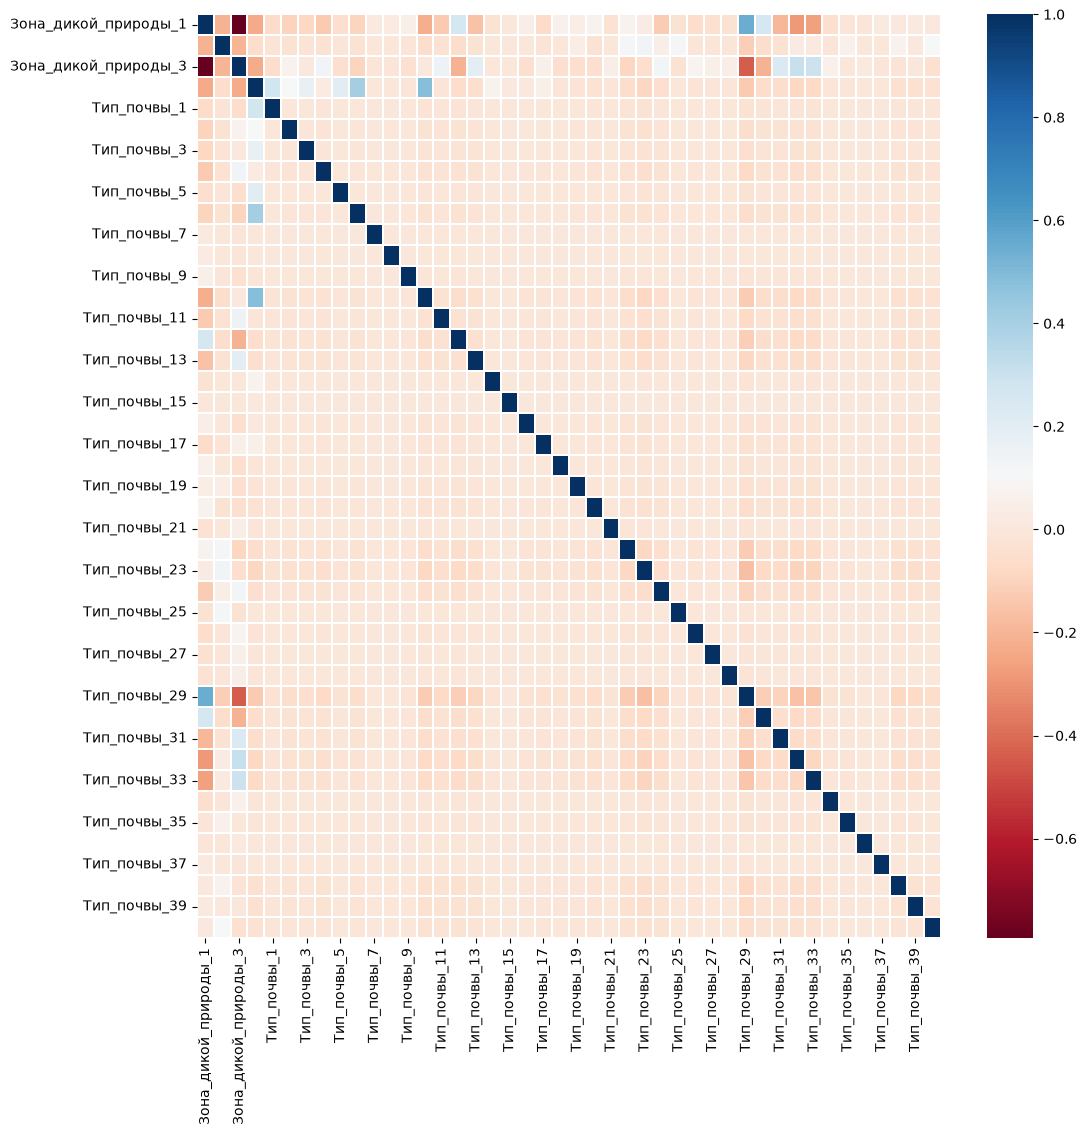

In [28]:
sns.heatmap(corr_matrix, annot=False, cmap='RdBu', linewidths=0.2, fmt='.2f')
fig=plt.gcf()
fig.set_size_inches(12,12)
plt.show()

## Анализ

### Про признаки

Как было указано ранее имеющиеся категориальные признаки являются результатом кодирования One Hot Encoding и представляют собой "разложение" двух категориальных на 44 бинарных признака. Это напрямую влияет на результаты вычисления матрицы корреляций:

1. Размерность матрицы затрудняет анализ
2. По определению разные типы почв являются взаимоисключающими. Следственно между столбцами возникает отрицательная корреляция.

### Выводы

Опустив из внимания зависимости бинарных признаков от сходных их получаем, что ряд типов почв имеют видимую корреляцию с конкретными зонами:
* *Тип почвы 29* и *Зона 1* (0.55) — самая сильная положительная корреляция в матрице. Данный тип почвы преимущественно локализован в первой зоны.
* *Тип почвы 10* и *Зона 4* (0.49) — также ярко выраженная положительная связь.

Таким образом, существуют устойчивые закономерности заповедной зоны и типа почвы в ней, однако большинство категориальных признаков не коррелируют.

In [30]:
corr_numeric = df[numeric_cols].corr(method='spearman')
corr_numeric

,Высота_над_уровнем_моря,Азимут_склона,Уклон_склона,Расстояние_до_воды_гориз,Расстояние_до_воды_верт,Расстояние_до_дорог,Освещённость_9_утра,Освещённость_полдень,Освещённость_3_дня,Расстояние_до_пожарных_точек
Высота_над_уровнем_моря,1.000000,0.044060,-0.160297,0.287402,0.086931,0.341590,0.015100,0.150427,0.072750,0.154851
Азимут_склона,0.044060,1.000000,0.072005,0.004692,0.073052,0.019418,-0.428957,0.421134,0.640536,-0.112724
Уклон_склона,-0.160297,0.072005,1.000000,0.019206,0.301333,-0.205023,-0.131244,-0.434180,-0.173474,-0.169574
Расстояние_до_воды_гориз,0.287402,0.004692,0.019206,1.000000,0.619386,0.047026,-0.041990,0.028134,0.037528,0.073760
Расстояние_до_воды_верт,0.086931,0.073052,0.301333,0.619386,1.000000,-0.037963,-0.128754,-0.095524,0.037780,-0.043495
Расстояние_до_дорог,0.341590,0.019418,-0.205023,0.047026,-0.037963,1.000000,-0.009994,0.173793,0.102471,0.322301
Освещённость_9_утра,0.015100,-0.428957,-0.131244,-0.041990,-0.128754,-0.009994,1.000000,-0.101311,-0.823424,0.124450
Освещённость_полдень,0.150427,0.421134,-0.434180,0.028134,-0.095524,0.173793,-0.101311,1.000000,0.573942,0.017162
Освещённость_3_дня,0.072750,0.640536,-0.173474,0.037528,0.037780,0.102471,-0.823424,0.573942,1.000000,-0.082736
Расстояние_до_пожарных_точек,0.154851,-0.112724,-0.169574,0.073760,-0.043495,0.322301,0.124450,0.017162,-0.082736,1.000000


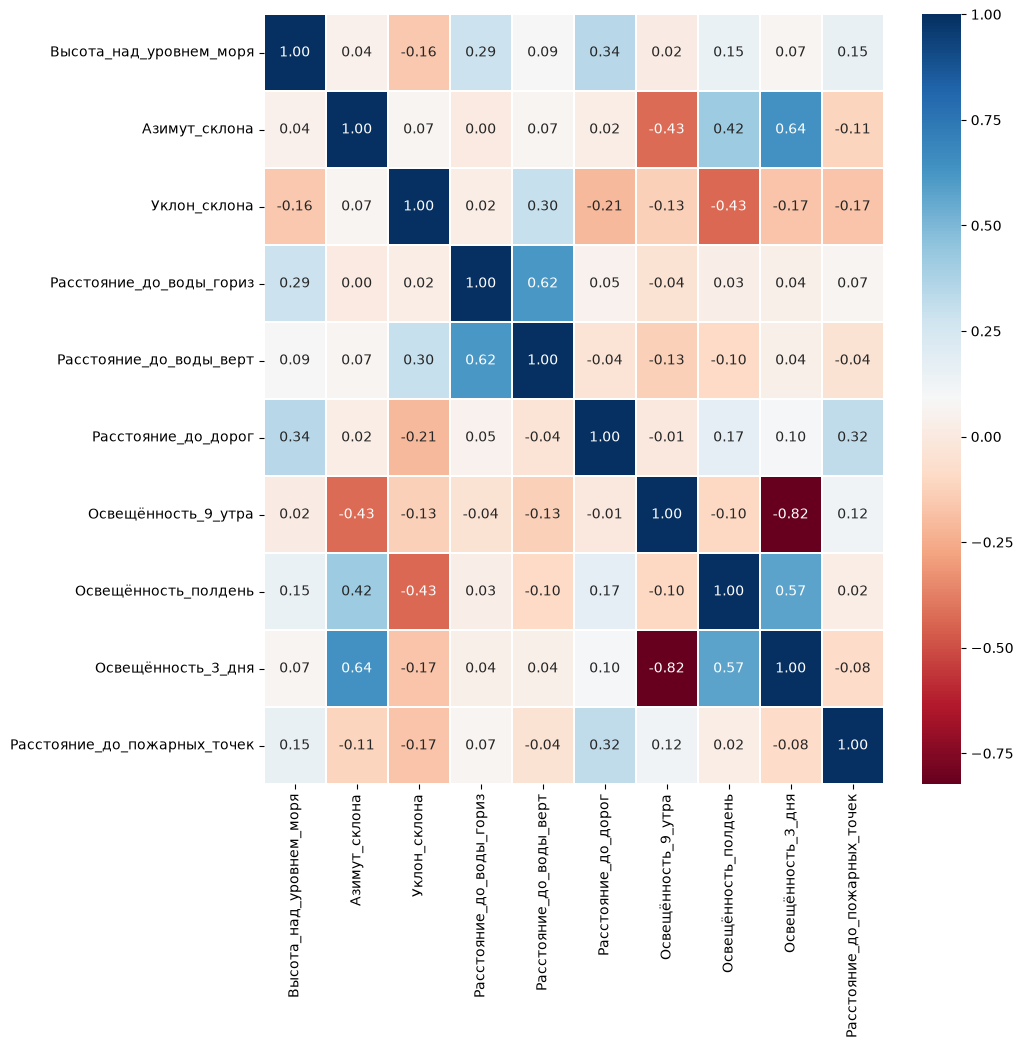

In [32]:
sns.heatmap(corr_numeric, annot=True, cmap='RdBu', linewidths=0.2, fmt='.2f')
fig=plt.gcf()
fig.set_size_inches(10,10)
plt.show()

## Анализ

Согласно методичке, для порядковых переменных, а также в случаях, когда хотя бы одна из переменных не является нормально распределённой или содержит выбросы, следует использовать коэффициент Спирмана. 

### Коррелируемые показатели

Наиболее коррелируемыми показателями являются:

1. *Освещённость 9 тра* и *Освещённость 3дня* (-0.82) - самая сильная связь среди числовых признаков. Отрицательная корреляция объясняется тем, что участки, хорошо освещённые утром, как правило, хуже освещены во второй половине дня, и наоборот.
2. *Расстояние до воды гориз* и *Расстояние до воды верт* (0.62) - положительная связь. Оба признака описывают близость участка к воде: если участок расположен недалеко от водоёма в горизонтальном измерении, то и вертикальное расстояние обычно мало.
3. *Азимут_склона* и *Освещённость_3_дня* (0.64) — положительная связь. Ориентация склона напрямую определяет, насколько хорошо участок освещён во второй половине дня.
4. *`Освещённость полдень* и *Освещённость 3 дня* (0.57) - положительная связь. Здесь возможно роль играет близкое расположения на временном интервале дня. То есть при хорошей освещенности в полдень велика вероятность сохранения освещенности позднее, через три часа.

Также выделяется группа признаком с меньшим, но все же заметным коэффициентом корреляции:

1. *Азимут склона* и *Освещённость 9 утра* (-0.43) - отрицательная связь. Склоны, ориентированные на восток, лучше освещены утром.
2. *Азимут склона* и *Освещённость полдень* (0.42) - аналогично первому.
3. *Уклон_склона* и *Освещённость полдень* (-0.43) - отрицательная связь. Крутые склоны могут затеняться в полдень.
4. *Высота над ровнем моря* и *Расстояние до дорог* (0.34) - положительная связь. Участки на большей высоте обычно расположены дальше от дорог.
5. *Расстояние до дорог* и *Расстояние до пожарных точек* (0.32) — положительная связь. Возможно, что дороги и пожарные станции расположены рядом

Таким образом, все выявленные взаимосвязи имеют обоснование и связаны по большей части природными факторами

In [40]:
target = 'Расстояние_до_дорог'
q1 = df[target].quantile(0.25)
q3 = df[target].quantile(0.75)
iqr = q3-q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f'q1={q1}')
print(f'q3={q3}')
print(f'iqr={iqr}')
print(f'Range ({lower} ; {upper})')

outliers = df[(df[target] < lower) | (df[target] > upper)] 
print(f'Number of outliers: {len(outliers)}', f'Outliers: {outliers[target]}', sep='\n')

q1=1106.0
q3=3328.0
iqr=2222.0
Range (-2227.0 ; 6661.0)
Number of outliers: 669
Outliers: 93       6836
96       6811
106      6679
121      6890
11375    6766
         ... 
32401    6682
32402    6692
32403    6664
32789    6668
32790    6672
Name: Расстояние_до_дорог, Length: 669, dtype: int64


## Анализ 

Был рассчитан диапазон "типичных" значений признака *Расстояние до дорог* по [методу межквартильного размаха](https://elib.spbstu.ru/dl/2/3653.pdf/download/3653.pdf). В данном методе все наблюдения, выходящие за пределами экстремумов, являются выбросами. Получаем:

* Q1 = 1106
* Q3 = 3328
* IQR = 2222
* Нижняя граница диапазона = -2227
* Верхняя граница диапазона = 6661

Нижняя граница, исходя из рациональности, является недостатком вычисления и фактически равна нулю.

За верхней границей диапазона (6661) обнаружено 669 наблюдений, при этом нижних нет.

Обнаруженные значения — это особенности данных, а не ошибки измерения, так как все значения лежат в узком диапазоне вблизи верхней границы.

## Вывод

В лабораторной работе использовался датасет Forest Cover Types с площадки Kaggle, содержащий информацию о типах лесного покрова для территорий национального парка Рузвельта в Колорадо. Датасет включает 581 012 записей и 55 столбцов, среди которых 10 непрерывных числовых признаков, 44 бинарных категориальных признака и одна целевая переменная Cover_Type с 7 классами. Все столбцы имеют тип int64, пропущенных значений нет, что делает датасет хорошо подготовленным для анализа. Особенностью структуры является то, что стандартное разделение на числовые и категориальные признаки по типу данных здесь не работает, поэтому категориальные признаки были выделены эвристическипо количеству уникальных значений. Числовые признаки описывают высоту, уклон, ориентацию склона, расстояния до воды, дорог и пожаров, а также освещённость в разное время суток. Категориальные признаки представлены бинарными индикаторами зон дикой природы и типов почв. Наиболее информативными статистическими характеристиками в ходе анализа оказались медиана и квартили. Они позволили устойчиво описать распределение в условиях асимметрии и наличия выбросов и послужили основой для формального поиска выбросов. 

Для анализа взаимосвязей признаков использовался коэффициент Спирмена, поскольку распределения асимметричны и содержат выбросы, а условия применения Пирсона не выполняются. Здесь был выявлен ряд зависимостей, относящихся как к категориальным, так и к числовым признакам. Корреляций между числовыми признаками оказалось больше, чем между категориальными ввиду природы данных. Распределения значений в датасете неоднородны. Признаки Высота_над_уровнем_моря и Освещённость_3_дня близки к симметричным — их среднее, медиана и мода почти совпадают. Напротив, все признаки, связанные с расстояниями, имеют ярко выраженную асимметрию. 

В данных потенциально присутствует большое количество выбросов. Так для признака Расстояние_до_дорог за верхней границей IQR было обнаружено 669 наблюдений. Анализ этих значений показал, что они не являются ошибками измерения, так как лежат в узком диапазоне значений. В целом, на этапе анализа базовых метрик было замечено, что у всех признаков, связанных с расстоянием, среднее значительно превышает медиану, а дальнейший анализ подтвердил опасения. Все описанные момемнты могуть свидетельствовать о наличии выбросов.

Качество данных в целом оказалось на неплохом уровне, однако при работе стоит учитывать масштаб данных, дисбаланс категориальных признаков, особенно редкие типы, выбросы и ассиметрию некоторых признаков.